In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from matplotlib.colors import ListedColormap, BoundaryNorm, LinearSegmentedColormap, Normalize
from mpl_toolkits.mplot3d.art3d import Line3DCollection
from matplotlib.cm import ScalarMappable
from matplotlib.colors import LogNorm
import matplotlib as mpl

import torch
import dnnlib.util_v7 as util
from tqdm import tqdm
import pickle
from matplotlib.ticker import FuncFormatter
import pickle, types
from torch_utils import persistence

from PIL import Image

import numpy as np
import pickle
import os
import re 
import json 
import click
import torch
from torch_utils import distributed as dist
from training import toy_training_loop_vfm_noDataGen
from tqdm import tqdm
import matplotlib.pyplot as plt
from matplotlib import colors
from plot_neural_v7 import *
from plot_sim_results_v7 import *
from plot_sim_results_img_v7 import * 


import pandas as pd

import warnings
warnings.filterwarnings('ignore', 'Grad strides do not match bucket view strides') # False warning 
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.set_default_device(device)
colorgrad = "PuOr"

# 0. Some functions...

In [2]:
def plot_traj_3d(X):
    X = np.asarray(X)                    # (T, 3)
    T = len(X)
    t = np.arange(T)

    # line segments between consecutive points
    segs = np.stack([X[:-1], X[1:]], axis=1)   # (T-1, 2, 3)

    fig = plt.figure(figsize=(6,5))
    ax = fig.add_subplot(projection='3d')

    norm = mpl.colors.Normalize(vmin=0, vmax=T-1)
    cmap = plt.get_cmap()               # use current default colormap

    lc = Line3DCollection(segs, cmap=cmap, norm=norm, linewidth=2)
    lc.set_array(t[1:])                 # color by time index of segment end
    ax.add_collection3d(lc)

    # (optional) show the sampled points too
    ax.scatter(X[:,0], X[:,1], X[:,2], c=t, s=12, cmap=cmap, norm=norm)

    # nice bounds/aspect
    lo, hi = X.min(0), X.max(0)
    ax.set_xlim(lo[0], hi[0]); ax.set_ylim(lo[1], hi[1]); ax.set_zlim(lo[2], hi[2])
    ax.set_box_aspect(hi - lo)

    ax.set_xlabel('x'); ax.set_ylabel('y'); ax.set_zlabel('z'); ax.set_title('3D Trajectory (color = time)')
    fig.colorbar(lc, ax=ax, pad=0.02, fraction=0.05, label='time step')
    plt.tight_layout()
    plt.show()

In [3]:
def latent_mu(latent_traj_list, encoder, dim_preserve, device, fullRes=False,
              min_var=None, rcond=None, resid_tol=1e-10, use_fp64=True):
    """
    Orthonormal-L case:
        Z ≈ bias + L sqrt(D) μ  with  L^T L = I
        ⇒ μ_K = D_K^{-1/2} L_K^T (Z - bias)

    Accepts each list item as [T,d], [T,H,W], or [T,C,H,W].
    """
    import torch
    enc = encoder.to(device).eval()
    mu_traj, loading = [], None

    def _flatten_Tx(z: torch.Tensor) -> torch.Tensor:
        return z.view(z.size(0), -1)

    with torch.inference_mode():
        # Get globals once
        dummy = torch.zeros(
            1, enc.img_ch, enc.img_size, enc.img_size,
            device=device, dtype=torch.float32
        )
        _, D, L, bias = enc.encode(dummy, return_data_mean=True)

        # D is full diag; only first K are used
        d_vec = torch.diagonal(D) if D.ndim == 2 else D
        d_len = d_vec.numel()
        K = int(min(getattr(enc, 'k_max', d_len), d_len))

        mv = (max(1e-12, 1e-6 * torch.median(d_vec).item())
              if min_var is None else float(min_var))
        d_safe = torch.clamp(d_vec, min=mv)
        d_sqrt = torch.sqrt(d_safe[:K])               # [K]
        inv_sqrt_d = d_sqrt.reciprocal()              # [K]

        # Orthonormal columns, use only first K
        L_K = L[:, :K]                                 # [d, K]

        def solve_mu_batch(Z):
            # Z: [T,...] -> [T,d]
            Z_flat = _flatten_Tx(Z).to(device=device, dtype=torch.float32)
            Zb = Z_flat - bias.unsqueeze(0).to(Z_flat.dtype)   # [T,d]

            ZbT = Zb.T  # [d,T]
            if use_fp64:
                Ld = L_K.double()
                ZbT = ZbT.double()
                invsd = inv_sqrt_d.double()
                Y = Ld.T @ ZbT                # [K,T]
                MUt = invsd.unsqueeze(1) * Y  # [K,T]
                mu_full = MUt.T.float()       # [T,K]
            else:
                Y = L_K.T @ ZbT               # [K,T]
                MUt = inv_sqrt_d.unsqueeze(1) * Y
                mu_full = MUt.T               # [T,K]

            return mu_full  # [T,K]

        bad = False
        for arr in latent_traj_list:
            Z = torch.from_numpy(arr).to(device=device, dtype=torch.float32)
            mu_full = solve_mu_batch(Z)                     # [T,K]
            Z_flat  = _flatten_Tx(Z).to(mu_full.dtype)      # [T,d]

            # Reconstruct for residual check
            loading_now = (L_K * d_sqrt.unsqueeze(0)).to(mu_full.dtype)  # [d,K]
            Z_hat = (loading_now @ mu_full.T).T + bias.to(mu_full.dtype)  # [T,d]

            r = (Z_hat - Z_flat).norm() / (Z_flat.norm() + 1e-12)
            if torch.isnan(mu_full).any() or torch.isinf(mu_full).any() or r > resid_tol:
                bad = True
                break

            mu_traj.append(mu_full[:, :dim_preserve].cpu())

        if bad:
            # Exact left inverse on span(L_K): W = D_K^{-1/2} L_K^T
            loading = L_K * d_sqrt.unsqueeze(0)             # [d,K]
            W = (L_K.T * inv_sqrt_d.unsqueeze(1)).float()   # [K,d]
            mu_traj = []
            for arr in latent_traj_list:
                Z = torch.from_numpy(arr).to(device=device, dtype=torch.float32)
                Zf = _flatten_Tx(Z)
                Zb = Zf - bias
                mu_full = (W @ Zb.T).T                      # [T,K]
                mu_traj.append(mu_full[:, :dim_preserve].cpu())

    if fullRes:
        # return effective loading L_K sqrt(D_K)
        if loading is None:
            loading = L_K * d_sqrt.unsqueeze(0)
        return mu_traj, d_vec, L_K, loading, bias
    return mu_traj


In [4]:
def read_model(folder, chk_pts):
    pkl_path = folder + chk_pts
    if not hasattr(persistence, "_orig_reconstruct"):
        persistence._orig_reconstruct = persistence._reconstruct_persistent_obj
    def _tolerant_reconstruct(meta):
        try:
            return persistence._orig_reconstruct(meta)
        except Exception:
            class _Stub: pass
            return _Stub()

    class PatchedUnpickler(pickle.Unpickler):
        def find_class(self, module, name):
            if module == "torch_utils.persistence" and name == "_reconstruct_persistent_obj":
                return _tolerant_reconstruct
            return super().find_class(module, name)

    with open(pkl_path, "rb") as f:
        model_all = PatchedUnpickler(f).load()

    net = model_all["ema"] if "ema" in model_all else model_all["net"]
    flow_net = net.unet_model  # Compressive flow (u_theta)
    dyn_net = net.vnet_model   # Dynamics flow (v_theta)
    encoder = net.encoder
    lag = infer_lag_k_from_dyn_net(dyn_net)
    return flow_net, dyn_net, encoder, lag

In [5]:
def plot_tau(T, out_imgs_tau, dset_samples, trial_idx, tau, title = None):
    plot_frame(dset_samples, T, trial_idx)
    plt.suptitle('true, trial = ' + str(trial_idx))
    plt.tight_layout()
    plot_frame(out_imgs_tau, T, trial_idx)
    if title is None:
        plt.suptitle('simulated- tau = ' + str(tau))
    else:
        plt.suptitle(title)
    plt.tight_layout()

In [6]:
def get_mu_from_encoder(encoder, data_flattent, dim_to_keep, trial_idx=None):
    import numpy as np
    encoder = encoder.to(device).eval()
    with torch.inference_mode():
        # normalize indices
        if trial_idx is None or trial_idx == 'all':
            indices = range(len(data_flattent))
        elif isinstance(trial_idx, slice):
            indices = range(len(data_flattent))[trial_idx]
        elif np.isscalar(trial_idx):
            indices = [int(trial_idx)]
        else:  # list/tuple/array
            indices = list(trial_idx)

        outs = []
        for idx in indices:
            X0 = torch.from_numpy(data_flattent[idx]).to(device=device, dtype=torch.float32)
            mu_data, D, L, _ = encoder.encode(X0)
            outs.append(mu_data[:, :dim_to_keep].detach().cpu().numpy())

    return np.concatenate(outs, axis=0)  # shape: (sum T_i, dim_to_keep)

In [7]:
def recon_check_x0(encoder, trial_check, T_check, dset_samples):
    encoder = encoder.to(device).eval()
    X1_ori = dset_samples[trial_check][T_check,0,:,:]
    data_flattent = [np.reshape(a, (a.shape[0], -1), order='C') for a in dset_samples]
    with torch.inference_mode():
        X1 = torch.from_numpy(data_flattent[trial_check][T_check,:]).to(device=device, dtype=torch.float32)
        X0 = encoder.rsample(X1)
    X0_back = X0.reshape(X0.shape[0], C, H, W)
    return X0_back[0,0,:,:].detach().cpu().numpy()

In [8]:
def recon_check_x0_allT(encoder, trial_check, dset_samples):
    encoder = encoder.to(device).eval()
    X1_ori = dset_samples[trial_check][T_check,0,:,:]
    data_flattent = [np.reshape(a, (a.shape[0], -1), order='C') for a in dset_samples]
    with torch.inference_mode():
        X1 = torch.from_numpy(data_flattent[trial_check]).to(device=device, dtype=torch.float32)
        X0 = encoder.rsample(X1)
    X0_back = X0.reshape(X0.shape[0], C, H, W)
    return X0_back.detach().cpu().numpy()

In [9]:
def mu_group_recon(bias,
                   loading_np: np.ndarray,
                   mu_all: np.ndarray,
                   mu_idx=None,             # int | list[int] | np.ndarray | slice | None
                   H: int = 28,
                   W: int = 28,
                   mean_img: np.ndarray = None,
                   clip=None):
    D = loading_np.shape[0]
    assert loading_np.ndim == 2
    K_load = loading_np.shape[1]          # number of latent dims in loading
    N, K_mu = mu_all.shape               # number of latent dims in mu_all
    assert H * W == D

    # normalize mu_idx to an integer index array IN LATENT SPACE
    if mu_idx is None:
        idx = np.arange(min(K_load, K_mu))
    elif isinstance(mu_idx, slice):
        idx = np.arange(min(K_load, K_mu))[mu_idx]
    else:
        arr = np.asarray(mu_idx)
        if arr.dtype == bool:
            idx = np.flatnonzero(arr)
        else:
            idx = arr.astype(int, copy=False).ravel()

    # sanity: all requested dims must exist in both loading and mu_all
    max_idx = int(idx.max()) if idx.size > 0 else -1
    assert max_idx < K_load, f"mu_idx uses dim {max_idx}, but loading has only {K_load} cols"
    assert max_idx < K_mu,   f"mu_idx uses dim {max_idx}, but mu_all has only {K_mu} cols"

    A_sub  = loading_np[:, idx]     # (D, K_sel)
    mu_sub = mu_all[:, idx]         # (N, K_sel)
    recon_flat = mu_sub @ A_sub.T   # (N, D)

    if mean_img is not None:
        mean_flat = mean_img.reshape(-1)
        assert mean_flat.size == D
        recon_flat = recon_flat + mean_flat

    recon_flat = recon_flat + bias
    recon = recon_flat.reshape(N, H, W)
    if clip is not None:
        lo, hi = clip
        recon = np.clip(recon, lo, hi)
    return recon


# 1. Read Data

In [10]:
folder_data = 'out/ball/no_t/data'
useCov = False

dataset_samples = np.load(folder_data + "/dataset_samples.npz", allow_pickle=True)
cov_static_samples = np.load(folder_data + "/cov_static_trunc_only.npz", allow_pickle=True)
dset_samples = to_list_of_arrays(dataset_samples['samples'])
cov_stat_samples = to_list_of_arrays(cov_static_samples['samples'])

In [11]:
is_image = (np.asarray(dset_samples[0]).ndim == 4)
if is_image:
    _, C, H, W = np.asarray(dset_samples[0]).shape
T_min = min(arr.shape[0] for arr in dset_samples)
T_max = max(arr.shape[0] for arr in dset_samples)

In [12]:
eps = 1e-2
padded = [np.pad(a, ((0, T_max-a.shape[0]), (0,0), (0,0), (0,0)), mode='constant', constant_values=np.nan)
          for a in dset_samples]                                              # -> (n_trial, T_max, C, H, W)
stacked = np.stack(padded, axis=0)
min_img = np.nanmin(stacked, axis=(0,1))                                      # shape (C,H,W)
max_img = np.nanmax(stacked, axis=(0,1))                                      # shape (C,H,W)
clamp_range = np.stack([min_img - eps, max_img + eps], axis=0).astype(np.float32)  # shape (2,C,H,W)

In [13]:
TRIAL_IDX = 0
T = T_max

In [14]:
data_flattent = [np.reshape(a, (a.shape[0], -1), order='C') for a in dset_samples]
data_flattent_all = np.concatenate(data_flattent, axis=0)

# 2. Read Models

In [15]:
folder = 'out/ball/no_t/00008-ball_dim50_lag0_ridge-prr-uncond-regularFM-gpus1-batch256-fp32'
flow_net4, dyn_net4, encoder4, lag = read_model(folder, '/network-snapshot-003512.pkl')

In [16]:
print("k_max =", encoder4.k_max, "use_pop_stats =", encoder4.use_pop_stats)

k_max = 200 use_pop_stats = True


In [17]:
# check reconstruction
trial_check = 0
T_check = 0
X0_back4 = recon_check_x0(encoder4, trial_check, T_check, dset_samples = dset_samples)

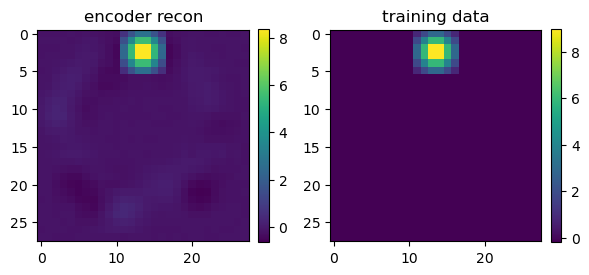

In [18]:
fig, axs = plt.subplots(1, 2, figsize=(6, 5))

im1 = axs[0].imshow(X0_back4)
fig.colorbar(im1, ax=axs[0], fraction=0.046, pad=0.04)  # smaller, aligned
axs[0].set_title('encoder recon')

im2 = axs[1].imshow(dset_samples[trial_check][T_check,0,:,:])
fig.colorbar(im2, ax=axs[1], fraction=0.046, pad=0.04)  # same settings
axs[1].set_title('training data')

plt.tight_layout()
plt.show()

# 3. Simulate Trajectories

In [19]:
TRIAL_IDX = 0
n_step = T_max

## 3.1 Data space (tau = 1.0)

In [20]:
tau = 1.0
traj_sim_tau1_flattent, lag_cov_list = generate_traj_image_onthefly(dyn_net4.to(device),
                                                                    dset_samples, n_step,
                                                                    tau, device, lag,
                                                                    include_x0_tau=False,
                                                                    oracle=False,
                                                                    flow_net=None,
                                                                    clamp_range=clamp_range
                                                                    )

100%|███████████████████████████████████████████| 49/49 [00:02<00:00, 22.77it/s]


In [21]:
out_imgs_tau1 = [arr.reshape(arr.shape[0], C, H, W) for arr in traj_sim_tau1_flattent]

/home/ganchao/Desktop/Velocity_Flow_Matching-global_new_param_new_pt/plot_sim_results_img_v7.py:77: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/tmp/ipykernel_1771892/2225081635.py:4: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/tmp/ipykernel_1771892/2225081635.py:10: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


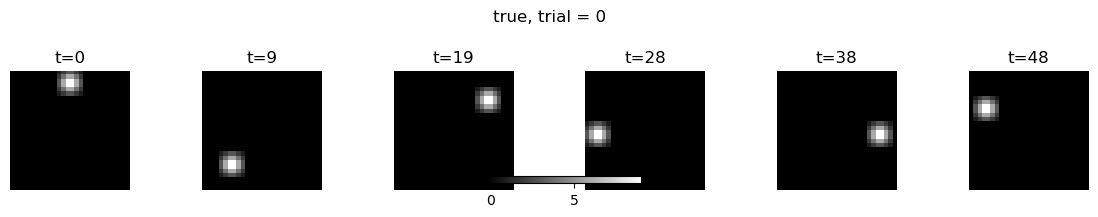

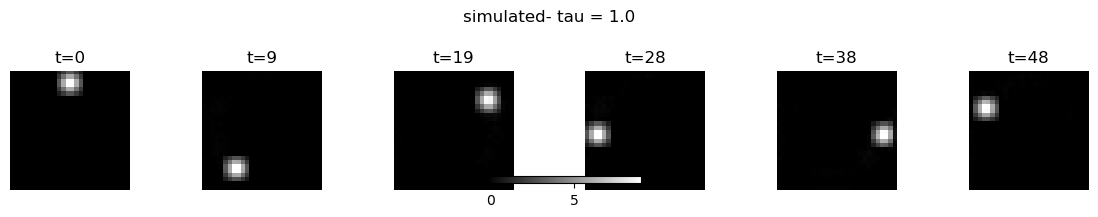

In [22]:
plot_tau(n_step, out_imgs_tau1, dset_samples, trial_idx = TRIAL_IDX, tau = 1.0)

## 3.2 Latent space (tau = 0.0)

In [23]:
out_imgs_tau0_flow_flatten = proj_to_latent(out_imgs_tau1, flow_net4.to(device), 0.0, device)
out_imgs_tau0_flow = [arr.reshape(arr.shape[0], C, H, W) for arr in out_imgs_tau0_flow_flatten ]

100%|███████████████████████████████████████████| 10/10 [00:01<00:00,  5.41it/s]


In [24]:
tau = 0.0
traj_sim_tau0_flattent, _ = generate_traj_image_onthefly(dyn_net4.to(device),
                                                         dset_samples, n_step,
                                                         tau, device, lag,
                                                         include_x0_tau=False,
                                                         oracle=False,
                                                         flow_net=flow_net4.to(device),
                                                         clamp_range=clamp_range
                                                         )
out_imgs_tau0 = [arr.reshape(arr.shape[0], C, H, W) for arr in traj_sim_tau0_flattent ]

100%|███████████████████████████████████████████| 49/49 [00:02<00:00, 24.34it/s]


/tmp/ipykernel_1771892/2225081635.py:4: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/tmp/ipykernel_1771892/2225081635.py:10: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


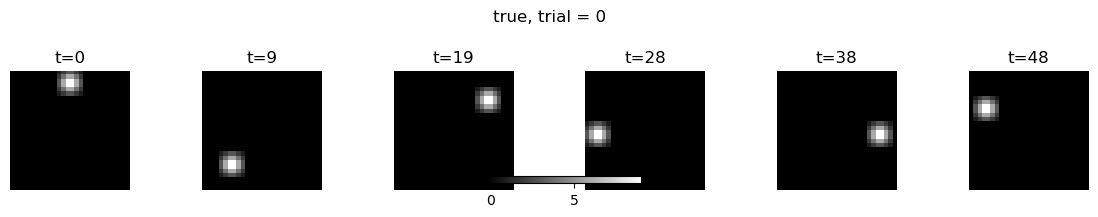

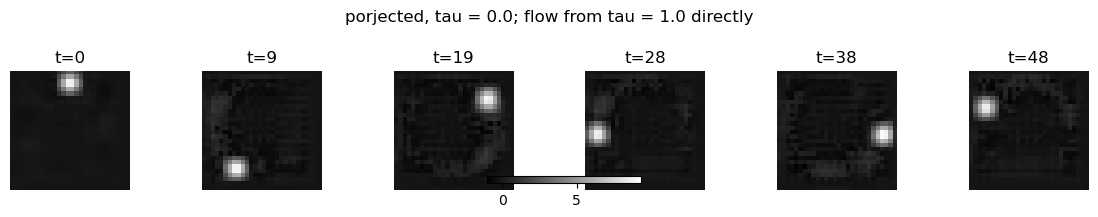

In [25]:
plot_tau(T, out_imgs_tau0_flow, dset_samples, trial_idx = TRIAL_IDX, tau = 0.0, title = 'porjected, tau = 0.0; flow from tau = 1.0 directly')

/tmp/ipykernel_1771892/2225081635.py:4: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/tmp/ipykernel_1771892/2225081635.py:10: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


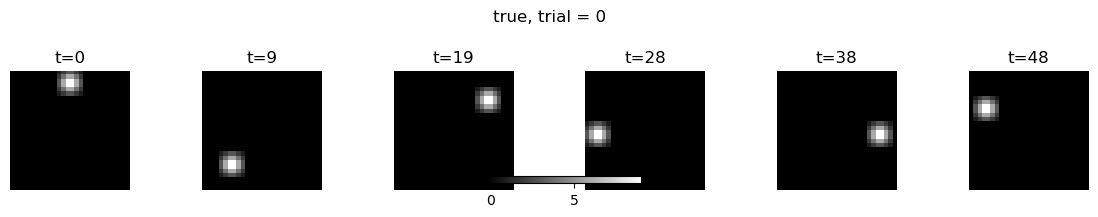

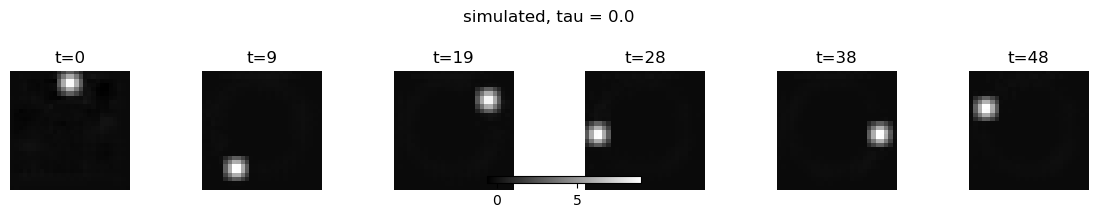

In [26]:
plot_tau(T, out_imgs_tau0, dset_samples, trial_idx = TRIAL_IDX, tau = 0.0, title = 'simulated, tau = 0.0')

# 4. Latent space

In [27]:
data_flattent = [np.reshape(a, (a.shape[0], -1), order='C') for a in dset_samples]

## 4.1 directly from encoder: mu(x_data)

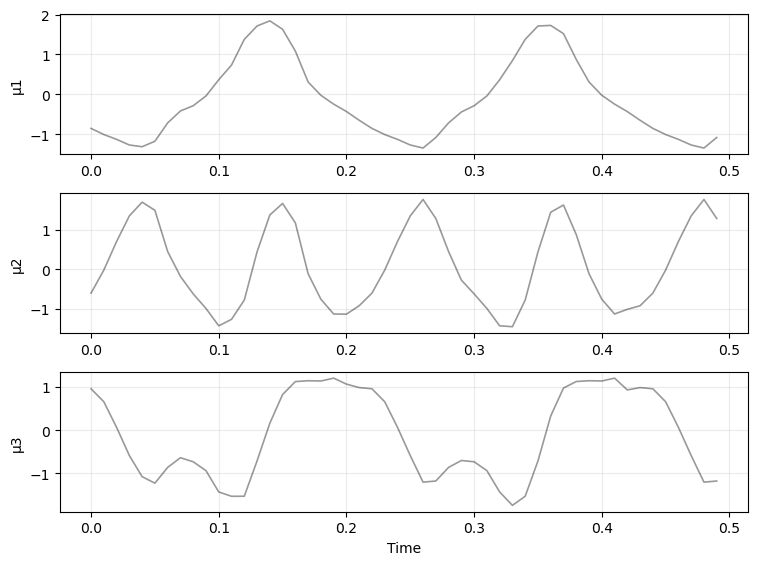

In [28]:
dim_to_keep = 3
mu_keep4 = get_mu_from_encoder(encoder4, data_flattent, dim_to_keep, TRIAL_IDX)
plot_latent_time_series([mu_keep4], alpha = 0.4, dims=np.arange(dim_to_keep), 
                        dt=0.01, labels=None)

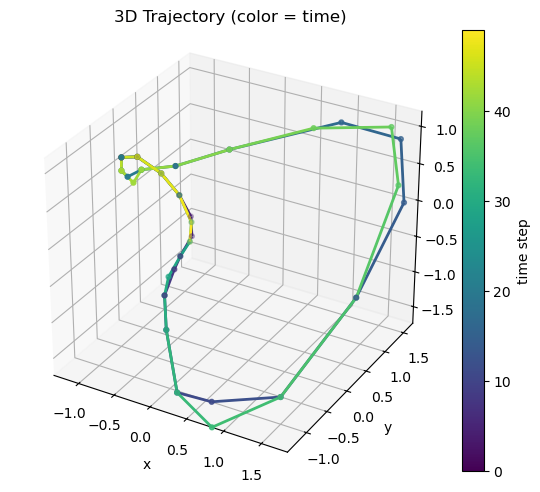

In [29]:
plot_traj_3d(mu_keep4)

In [30]:
mu_tmp, d, L, loading, bias = latent_mu(dset_samples, encoder4.to(device), dim_to_keep, device, fullRes = True)
L_np = L.detach().cpu().numpy()
d_np = d.detach().cpu().numpy()
loading_np = loading.detach().cpu().numpy()
mu_all = get_mu_from_encoder(encoder4, data_flattent, 28*28, TRIAL_IDX)

In [31]:
k_max = 200
k_target = 50
loading_norm_all = torch.norm(loading[:,0:k_max], dim= 0).detach().cpu().numpy()
energy = loading_norm_all ** 2 
cum_energy = np.cumsum(energy)
K_eff = 1 + np.searchsorted(cum_energy, 0.95 * cum_energy[-1])

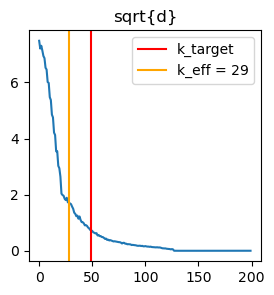

In [32]:
fig = plt.figure(figsize=(3, 3))
plt.plot(np.sqrt(d_np[0:k_max]))
plt.axvline(x=k_target-1, color='red', label = 'k_target')
plt.axvline(x=K_eff-1, color='orange', label = 'k_eff = ' + str(K_eff))
plt.title('sqrt{d}');
plt.legend()

Basically, $\sqrt{d_i}$ is loading column norm

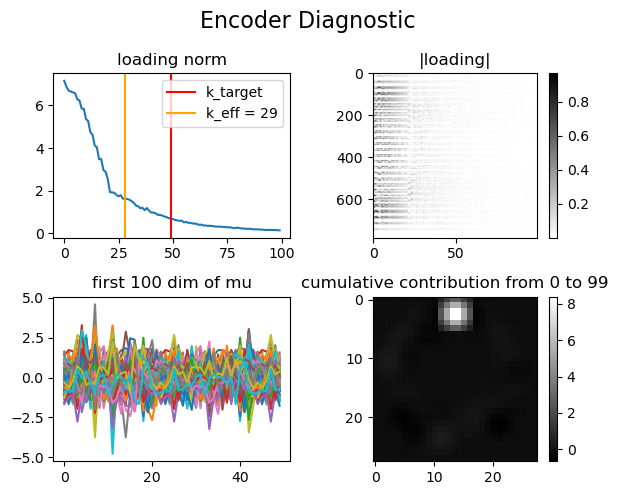

In [33]:
k_max = 200
dim_check_most = 100
k_target = 50
rows = loading.shape[0]
cols = dim_check_most
dim_check = np.arange(dim_check_most)
rec = mu_group_recon(bias.detach().cpu().numpy(), loading_np, mu_all, dim_check, H=28, W=28)
ball_idx = 0

fig, axs = plt.subplots(2, 2, figsize=(6, 5))
axs[0, 0].plot(loading_norm_all[:dim_check_most])
axs[0, 0].axvline(x=k_target-1, color='red', label = 'k_target')
axs[0, 0].axvline(x=K_eff-1, color='orange', label = 'k_eff = ' + str(K_eff))
axs[0, 0].set_title('loading norm')
axs[0, 0].legend()

im1 = axs[0, 1].imshow(np.abs(loading_np[:, 0:dim_check_most]), cmap='gray_r', aspect=cols / rows)
axs[0, 1].set_title('|loading|')
fig.colorbar(im1, ax=axs[0, 1])

axs[1, 0].plot(mu_all[:, :dim_check_most])
axs[1, 0].set_title('first ' + str(dim_check_most) + " dim of mu")

# Plot 4: cumulative contribution
im2 = axs[1, 1].imshow(rec[ball_idx], cmap='gray')
axs[1, 1].set_title('cumulative contribution from ' + str(dim_check[0]) + ' to ' + str(dim_check[-1]))
fig.colorbar(im2, ax=axs[1, 1])

fig.suptitle('Encoder Diagnostic', fontsize=16)
plt.tight_layout()
plt.show()

## 4.2 flowed/ project

In [34]:
dim_to_keep = 3
latent_traj_list = proj_to_latent(dset_samples, flow_net4.to(device), 0.0, device)

100%|███████████████████████████████████████████| 10/10 [00:01<00:00,  8.18it/s]


In [35]:
latent_traj_list_enc = []
for ii in range(len(dset_samples)):
    latent_traj_list_enc.append(recon_check_x0_allT(encoder4, ii, dset_samples))

In [36]:
# mu_traj_sim, d, L, loading, bias = latent_mu(latent_traj_list_enc, encoder4.to(device), dim_to_keep, device, fullRes = True)
mu_traj_sim, d, L, loading, bias = latent_mu(latent_traj_list, encoder4.to(device), dim_to_keep, device,
                                             fullRes = True, resid_tol=1e-15)

In [37]:
data_flow = [arr.reshape(arr.shape[0], C, H, W) for arr in latent_traj_list ]
data_enc = [arr.reshape(arr.shape[0], C, H, W) for arr in latent_traj_list_enc ]

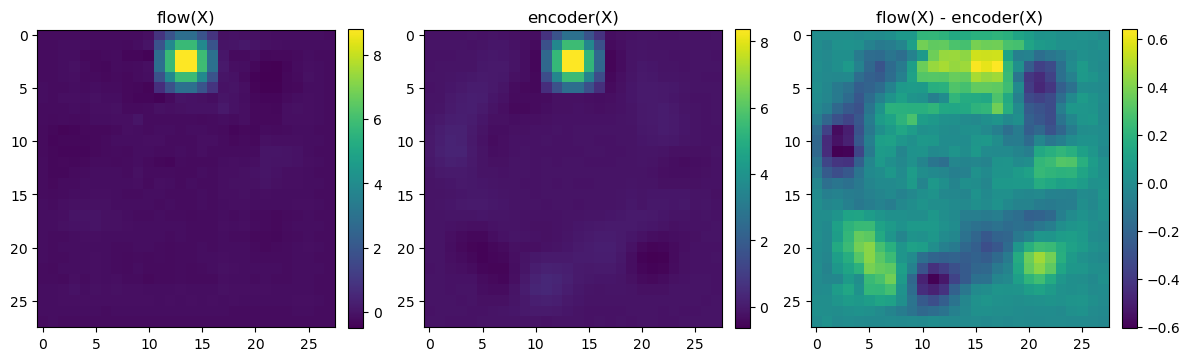

In [38]:
trial_check = 0
T_check = 0
fig, axs = plt.subplots(1, 3, figsize=(12, 10))

im1 = axs[0].imshow(data_flow[trial_check][T_check,0])
fig.colorbar(im1, ax=axs[0], fraction=0.046, pad=0.04)  # smaller, aligned
axs[0].set_title('flow(X)')

im2 = axs[1].imshow(data_enc[trial_check][T_check,0])
fig.colorbar(im2, ax=axs[1], fraction=0.046, pad=0.04)  # smaller, aligned
axs[1].set_title('encoder(X)')

im3 = axs[2].imshow(data_flow[trial_check][T_check,0] - data_enc[trial_check][T_check,0])
fig.colorbar(im3, ax=axs[2], fraction=0.046, pad=0.04)  # smaller, aligned
axs[2].set_title('flow(X) - encoder(X)')

plt.tight_layout()
plt.show()

Text(0.5, 0.98, 'flowed latent trajc for each trial')

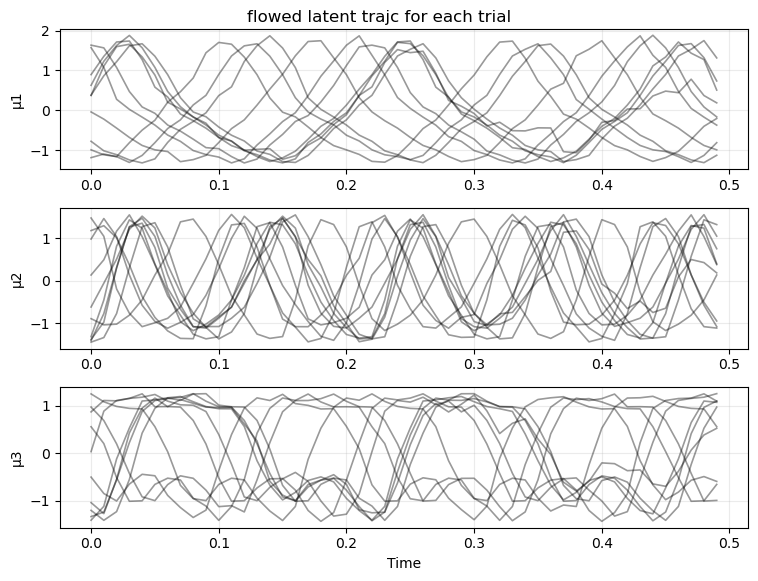

In [39]:
mu_traj_flow_np = [mu_traj_sim[j].cpu().numpy() for j in range(len(mu_traj_sim))]
plot_latent_time_series(mu_traj_flow_np, alpha = 0.4, dims=np.arange(dim_to_keep), 
                        dt=0.01, labels=None)
plt.suptitle('flowed latent trajc for each trial')

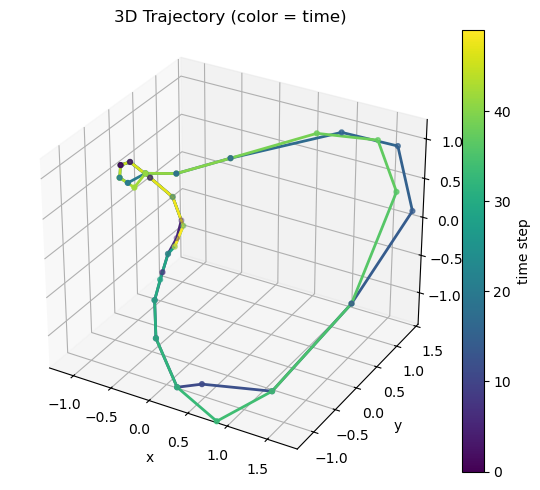

In [40]:
plot_traj_3d(mu_traj_flow_np[TRIAL_IDX][:,0:3])

## 4.3 simulated

In [41]:
dim_to_keep = 3
# data_flattent
mu_traj_sim, d, L, loading, bias = latent_mu(traj_sim_tau0_flattent, encoder4.to(device), dim_to_keep, device, fullRes = True)

Text(0.5, 0.98, 'simulated latent trajc for each trial')

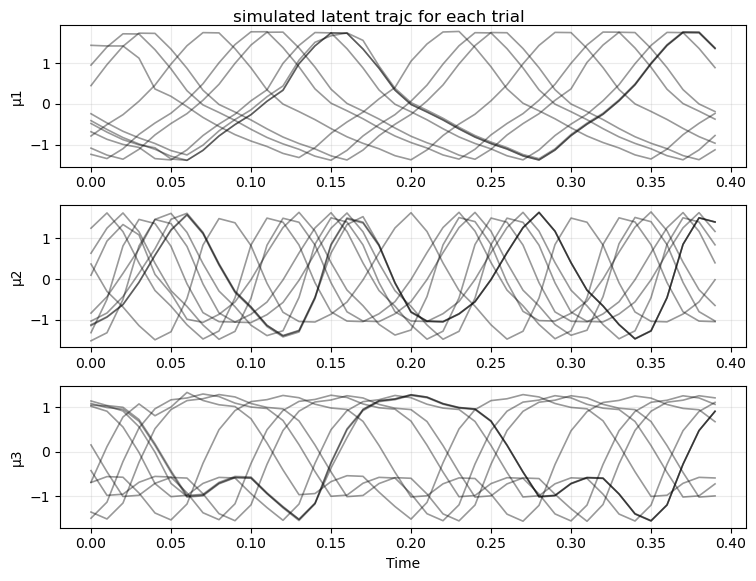

In [42]:
mu_traj_sim_np = [mu_traj_sim[j].cpu().numpy() for j in range(len(mu_traj_sim))]
mu_traj_sim_np_plot = [mu_traj_sim_np[ii][10:,:] for ii in range(len(mu_traj_sim_np))]
plot_latent_time_series(mu_traj_sim_np_plot, alpha = 0.4, dims=np.arange(dim_to_keep), 
                        dt=0.01, labels=None)
plt.suptitle('simulated latent trajc for each trial')

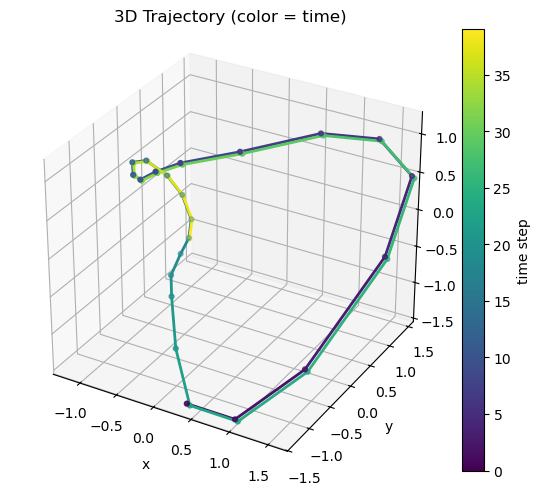

In [43]:
plot_traj_3d(mu_traj_sim_np_plot[TRIAL_IDX][:,0:3])

# Appendix: put all plots together

In [44]:
TRIAL_IDX = 9
T = T_max

/tmp/ipykernel_1771892/2225081635.py:4: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/tmp/ipykernel_1771892/2225081635.py:10: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


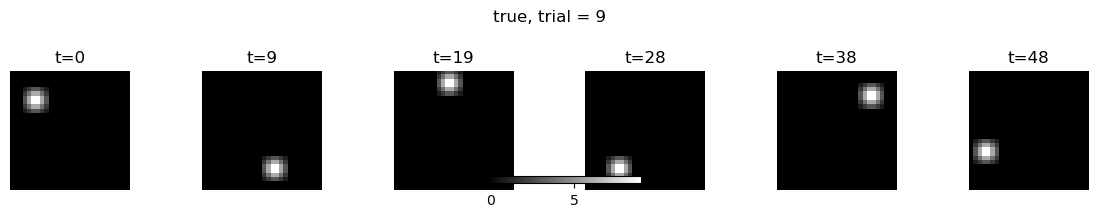

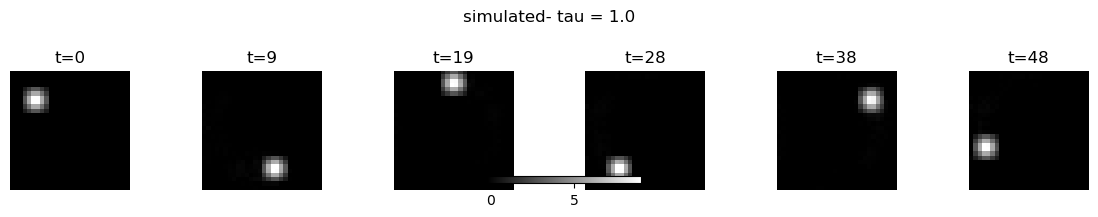

In [45]:
plot_tau(T, out_imgs_tau1, dset_samples, trial_idx = TRIAL_IDX, tau = 1.0)

/tmp/ipykernel_1771892/2225081635.py:4: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/tmp/ipykernel_1771892/2225081635.py:10: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


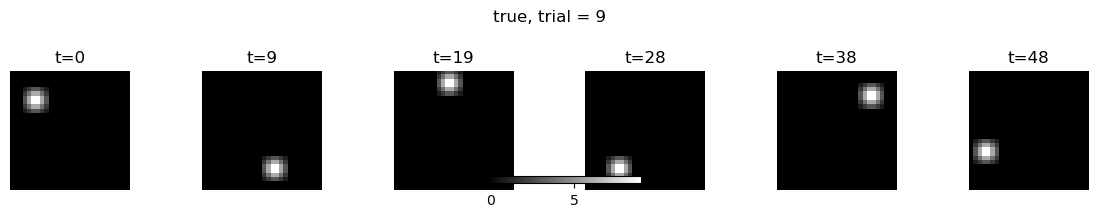

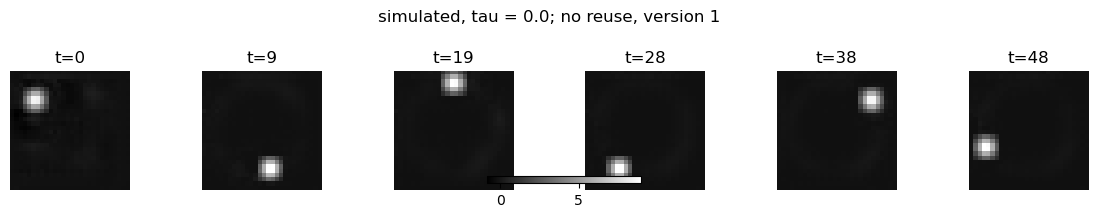

In [46]:
plot_tau(T, out_imgs_tau0, dset_samples, trial_idx = TRIAL_IDX, tau = 0.0, title = 'simulated, tau = 0.0; no reuse, version 1')